In [1]:
library(Seurat)
library(patchwork)
library(tidyverse) 
library(SingleR)
library(celldex)
library(SingleCellExperiment)
library(dplyr)

set.seed(1234)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


In [2]:
data_int <- "../../results/sc_rna/01_merge/intermediate"
# Define directories
dir_fig <- "../../results/sc_rna/02_preprocess/figures"
dir_int <- "../../results/sc_rna/02_preprocess/intermediate"

# Make sure directories exist
dir.create(dir_fig, recursive = TRUE, showWarnings = FALSE)
dir.create(dir_int, recursive = TRUE, showWarnings = FALSE)

# 1. Overall clustering

In [3]:
merged <- readRDS(file.path(data_int, "merged_pca.rds"))

In [4]:
merged

An object of class Seurat 
16245 features across 9527 samples within 1 assay 
Active assay: RNA (16245 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 dimensional reduction calculated: pca

In [5]:
# Build the neighbor graph, cluster cells, and compute UMAP/t-SNE embeddings
merged <- FindNeighbors(merged, dims = 1:30, reduction = "pca")
merged <- FindClusters(merged, resolution = 0.3)
merged <- RunUMAP(merged, dims = 1:30)
merged <- RunTSNE(merged, dims = 1:30)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 9527
Number of edges: 346651

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9437
Number of communities: 14
Elapsed time: 1 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
02:35:15 UMAP embedding parameters a = 0.9922 b = 1.112

02:35:15 Read 9527 rows and found 30 numeric columns

02:35:15 Using Annoy for neighbor search, n_neighbors = 30

02:35:15 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

02:35:16 Writing NN index file to temp file /tmp/RtmpssBY13/file2c996bcaa51

02:35:16 Searching Annoy index using 1 thread, search_k = 3000

02:35:19 Annoy recall = 100%

02:35:20 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


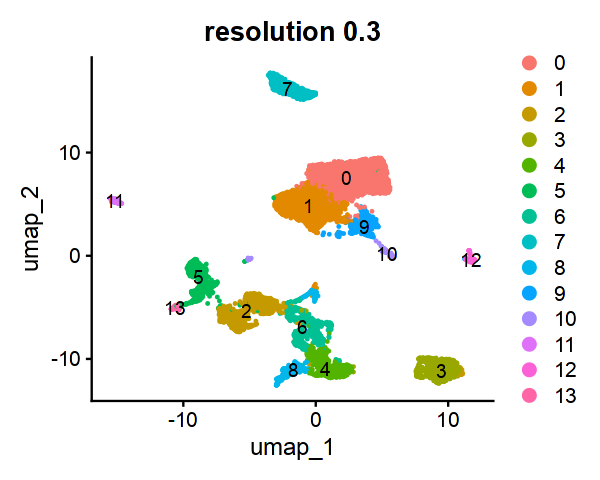

In [6]:
options(repr.plot.width = 5, repr.plot.height = 4)
DimPlot(merged, group.by = "seurat_clusters", label=TRUE) + labs(title = "resolution 0.3")

Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


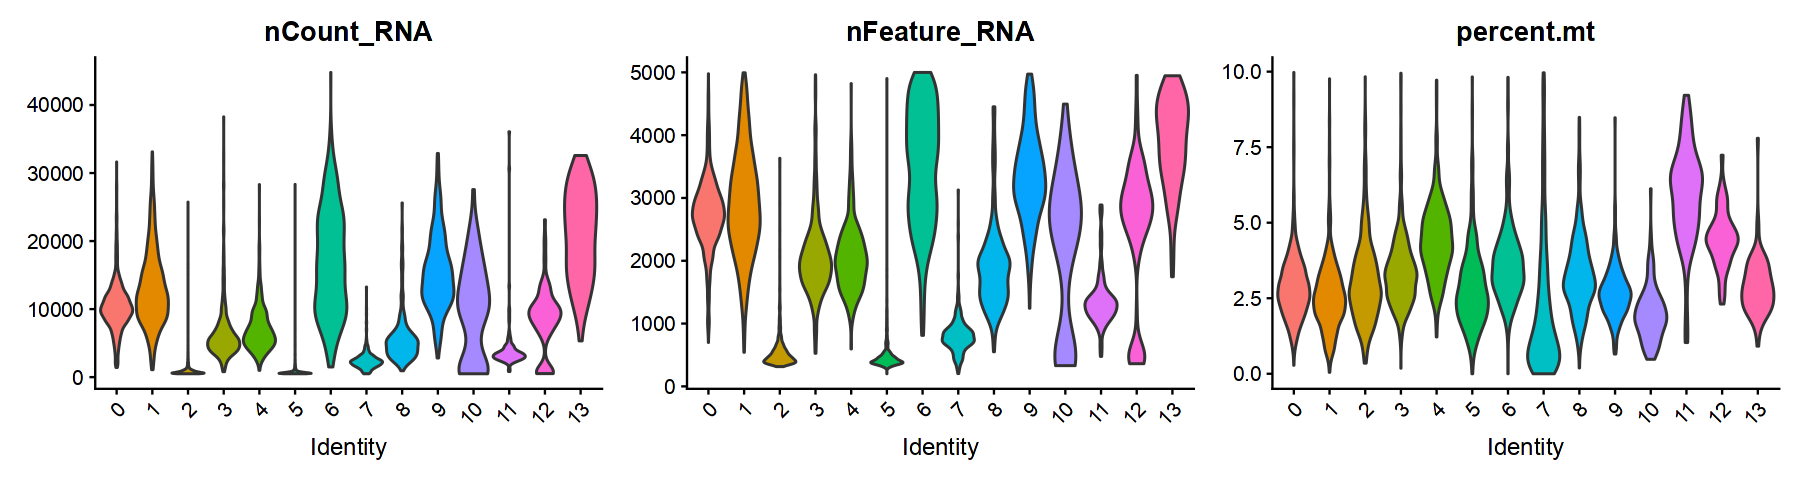

In [7]:
# Visualize QC metrics across clusters
options(repr.plot.width = 15, repr.plot.height = 4)
VlnPlot(
    merged,
    features = c("nCount_RNA", "nFeature_RNA", "percent.mt"),
    group.by = "seurat_clusters",
    ncol=3, 
    pt.size = 0
) + NoLegend()

In [8]:
saveRDS(merged, file = file.path(dir_int, "merged.rds"))

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’



# 2. Filter Low quality cells

In [9]:
# Remove selected clusters from the merged object
merged_filt <- subset(
    merged,
    idents = c("2", "5"),
    invert = TRUE
)

In [10]:
merged_filt

An object of class Seurat 
16245 features across 7798 samples within 1 assay 
Active assay: RNA (16245 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, tsne

In [11]:
merged_filt <- FindVariableFeatures(merged_filt, selection.method = "vst", nfeatures = 2000)
merged_filt <- ScaleData(merged_filt, features = rownames(merged_filt))
merged_filt <- RunPCA(merged_filt)

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  Ptprcap, Gimap4, Ms4a4b, Nkg7, Lck, Gimap6, Il2rb, Sh2d2a, Sept1, Cd2 
	   Skap1, Gimap3, Ptpn22, Gimap1, Ctsw, Ets1, Trbc1, Trbc2, Ctla2a, Gimap5 
	   Cd3g, Cd3d, AW112010, Ltb, Klrd1, Trac, Cd3e, Ablim1, Thy1, Gimap7 
Negative:  Ifitm3, Ftl1, Psap, Lgals3, Lyz2, Ifitm2, Ctsb, Cd14, Il1b, Ms4a6c 
	   Prdx5, Ctsc, Ifi204, Cybb, Fcgr1, Wfdc17, Fcgr2b, Ccl6, Plaur, Ninj1 
	   Cstb, Ccr1, Marcks, Gda, Csf2rb, Plin2, Ms4a6d, Tgfbi, Msr1, Grn 
PC_ 2 
Positive:  Mirt1, S100a8, S100a9, Klf2, G0s2, Ankrd33b, Cd9, Hdc, Hcar2, Clec4d 
	   Grina, Tnfrsf23, Egr1, Mirt2, Retnlg, E230032D23Rik, Klrb1c, Gadd45a, Csf3r, Txk 
	   Dedd2, Mmp9, Ccl3, Slc7a11, Il1f9, Arg2, Gzma, Acod1, Tnfrsf26, Slpi 
Negative:  Pclaf, Ccna2, Birc5, Tuba1b, Cdca8, Stmn1, Cdk1, Mki67, Spc24, Nusap1 
	   Cks1b, Cdca3, Tpx2, Kif11, Tk1, Aurkb, Cit, Rrm2, Top2a, Ptma 
	   Hist1h2ap, Ccnb2, Ube2c, Ncapg, Hist1h1b, Tacc3, Hsp90ab1, 

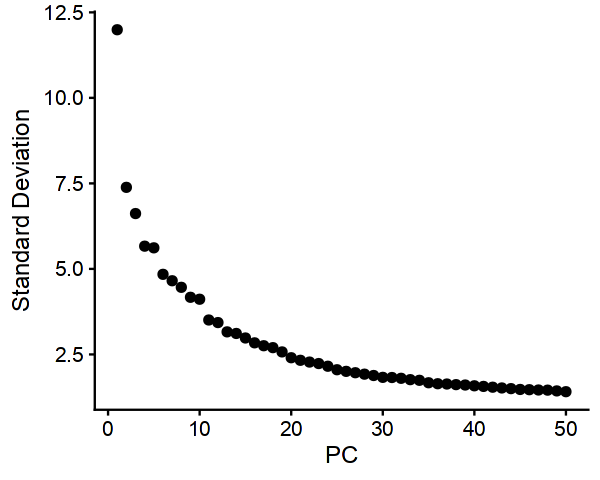

In [12]:
options(repr.plot.width = 5, repr.plot.height = 4)
ElbowPlot(merged_filt, ndims = 50)

In [13]:
merged_filt <- FindNeighbors(merged_filt, dims = 1:30)
merged_filt <- FindClusters(merged_filt, resolution = 0.5, 
                            cluster.name = "refilt_res.0.5")
merged_filt <- RunUMAP(merged_filt, dims = 1:30)
merged_filt <- RunTSNE(merged_filt, dims = 1:30)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7798
Number of edges: 275463

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9137
Number of communities: 16
Elapsed time: 0 seconds


02:38:28 UMAP embedding parameters a = 0.9922 b = 1.112

02:38:28 Read 7798 rows and found 30 numeric columns

02:38:28 Using Annoy for neighbor search, n_neighbors = 30

02:38:28 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

02:38:29 Writing NN index file to temp file /tmp/RtmpssBY13/file2c99682506cf

02:38:29 Searching Annoy index using 1 thread, search_k = 3000

02:38:31 Annoy recall = 100%

02:38:32 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

02:38:34 Initializing from normalized Laplacian + noise (using RSpectra)

02:38:35 Commencing optimization for 500 epochs, with 320060 positive edges

02:38:35 Using rng type: pcg

02:38:44 Optimization finished



In [14]:
head(merged_filt)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,day,RNA_snn_res.0.3,seurat_clusters,refilt_res.0.5
,<chr>,<dbl>,<int>,<dbl>,<fct>,<fct>,<fct>,<fct>
Day3_AAACCCACAGAAGCGT-1,day03,6319,1899,2.310492,Day3,1,3,3
Day3_AAACCCACAGCTTCGG-1,day03,10846,2735,2.636917,Day3,3,2,2
Day3_AAACCCATCAACGTGT-1,day03,1426,544,9.186536,Day3,7,6,6
Day3_AAACCCATCTGCTCTG-1,day03,15119,3407,2.215755,Day3,0,5,5
Day3_AAACGAATCCCGATCT-1,day03,6505,2183,2.997694,Day3,3,2,2
Day3_AAACGCTAGCGCCCAT-1,day03,6463,1616,2.661303,Day3,1,3,3
Day3_AAAGAACAGTGAGTTA-1,day03,6740,2251,3.635015,Day3,3,2,2
Day3_AAAGAACAGTGCTAGG-1,day03,20541,3603,5.131201,Day3,6,7,7
Day3_AAAGAACCAATAGAGT-1,day03,9158,2759,1.976414,Day3,1,0,0


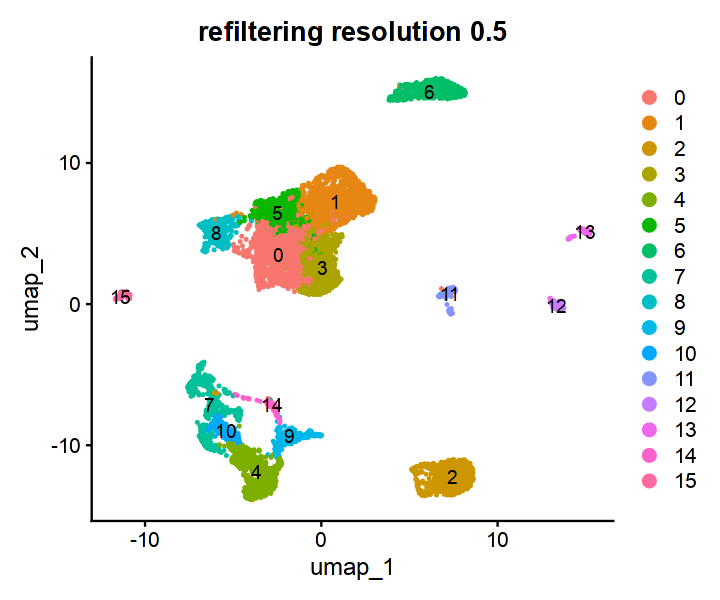

In [15]:
options(repr.plot.width = 6, repr.plot.height = 5)
DimPlot(merged_filt, group.by = "refilt_res.0.5", label=TRUE) + labs(title = "refiltering resolution 0.5")

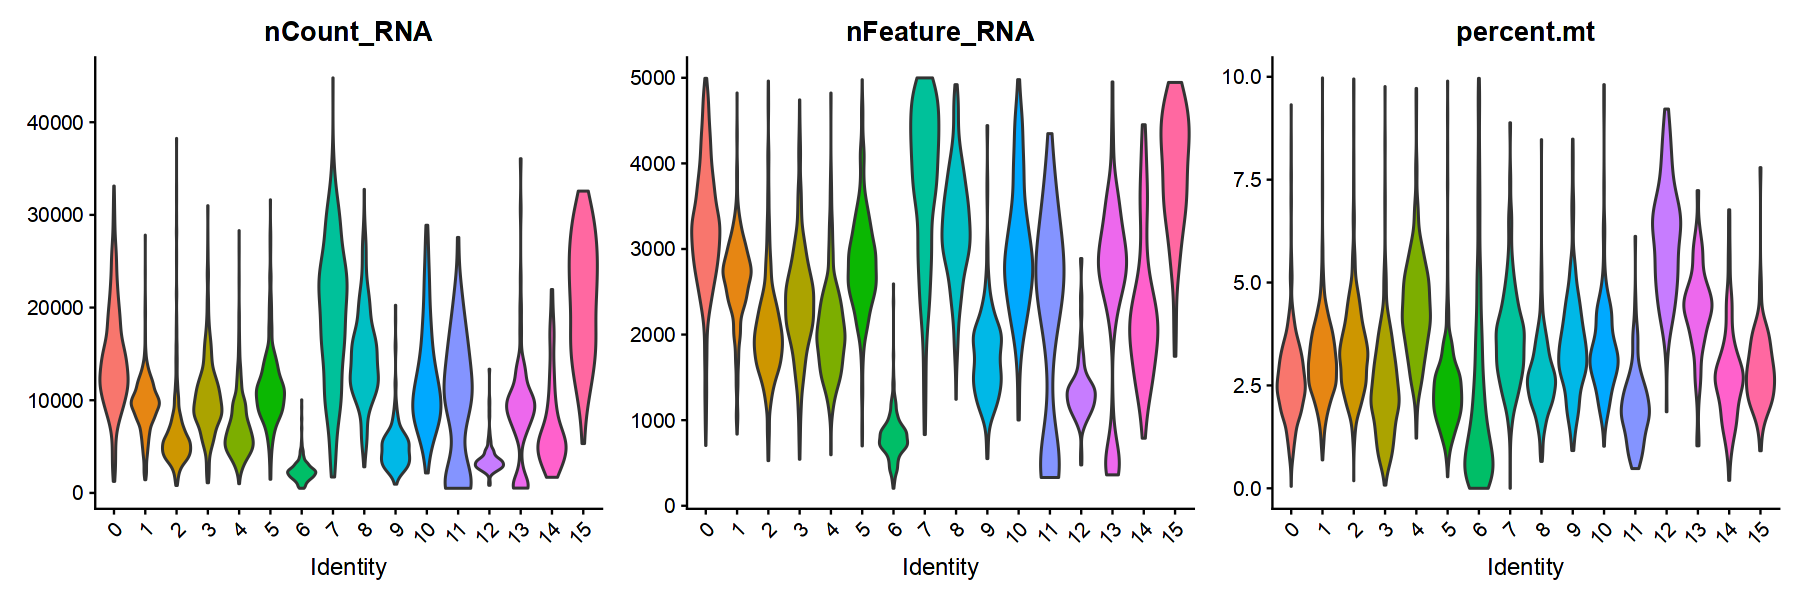

In [16]:
options(repr.plot.width = 15, repr.plot.height = 5)
p1 <- VlnPlot(
  merged_filt,
  features = c("nCount_RNA", "nFeature_RNA", "percent.mt"),
  pt.size = 0
) + NoLegend()

p1

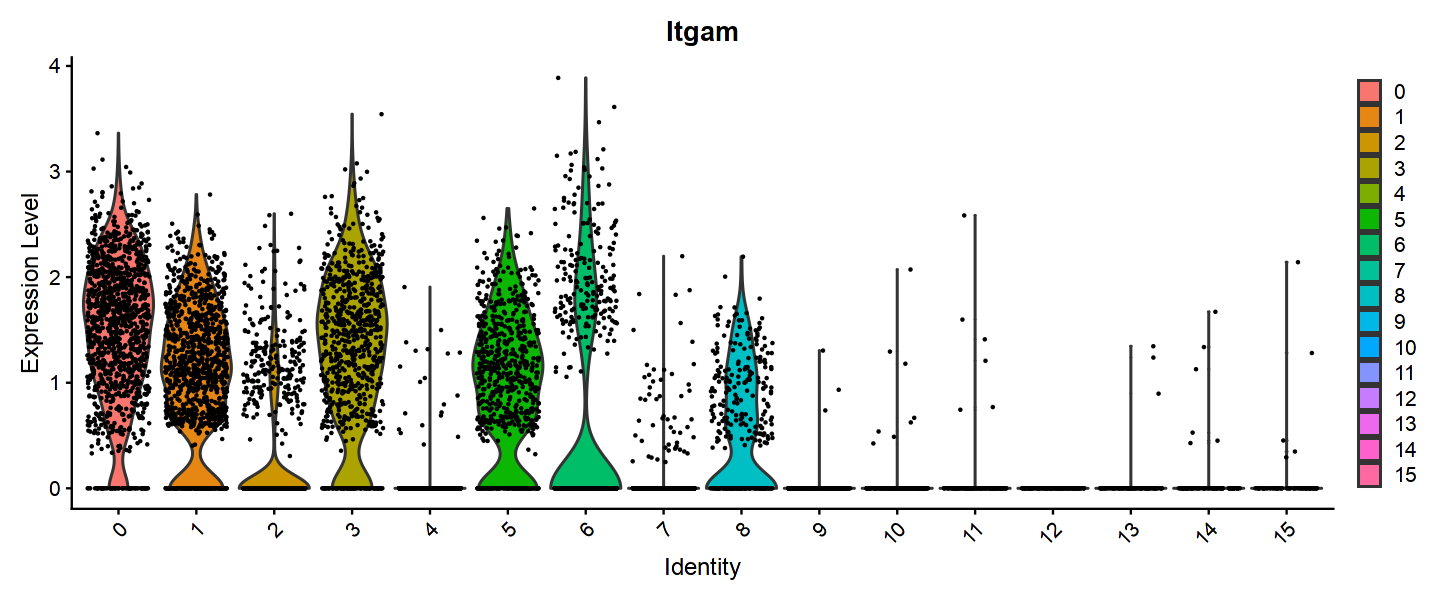

In [17]:
cluster_specific_genes1 <- c("Itgam")

options(repr.plot.width = 12,repr.plot.height = 5)
p3_2 <- VlnPlot(merged_filt, features = cluster_specific_genes1, ncol= 1, pt.size=0.01)
p3_2

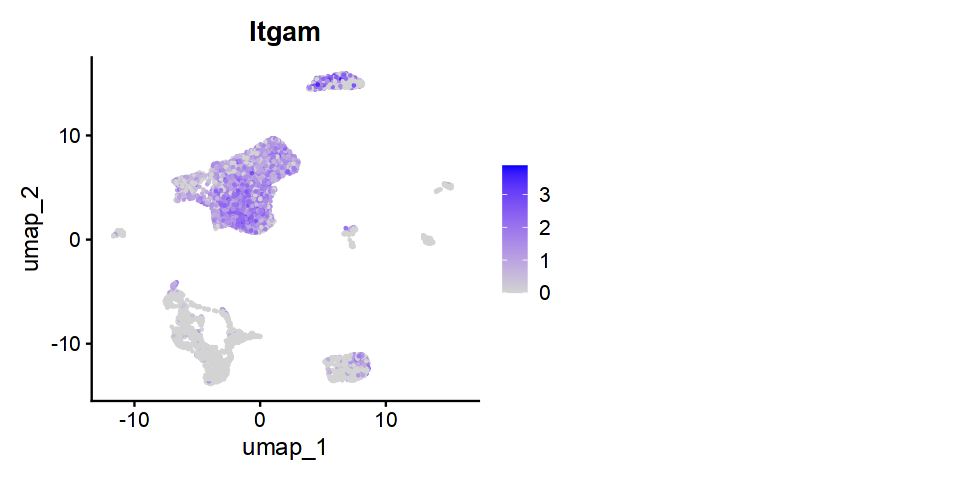

In [18]:
options(repr.plot.width = 8, repr.plot.height = 4)
FeaturePlot(merged_filt, features = c("Itgam"), pt.size = 0.1, ncol=2)

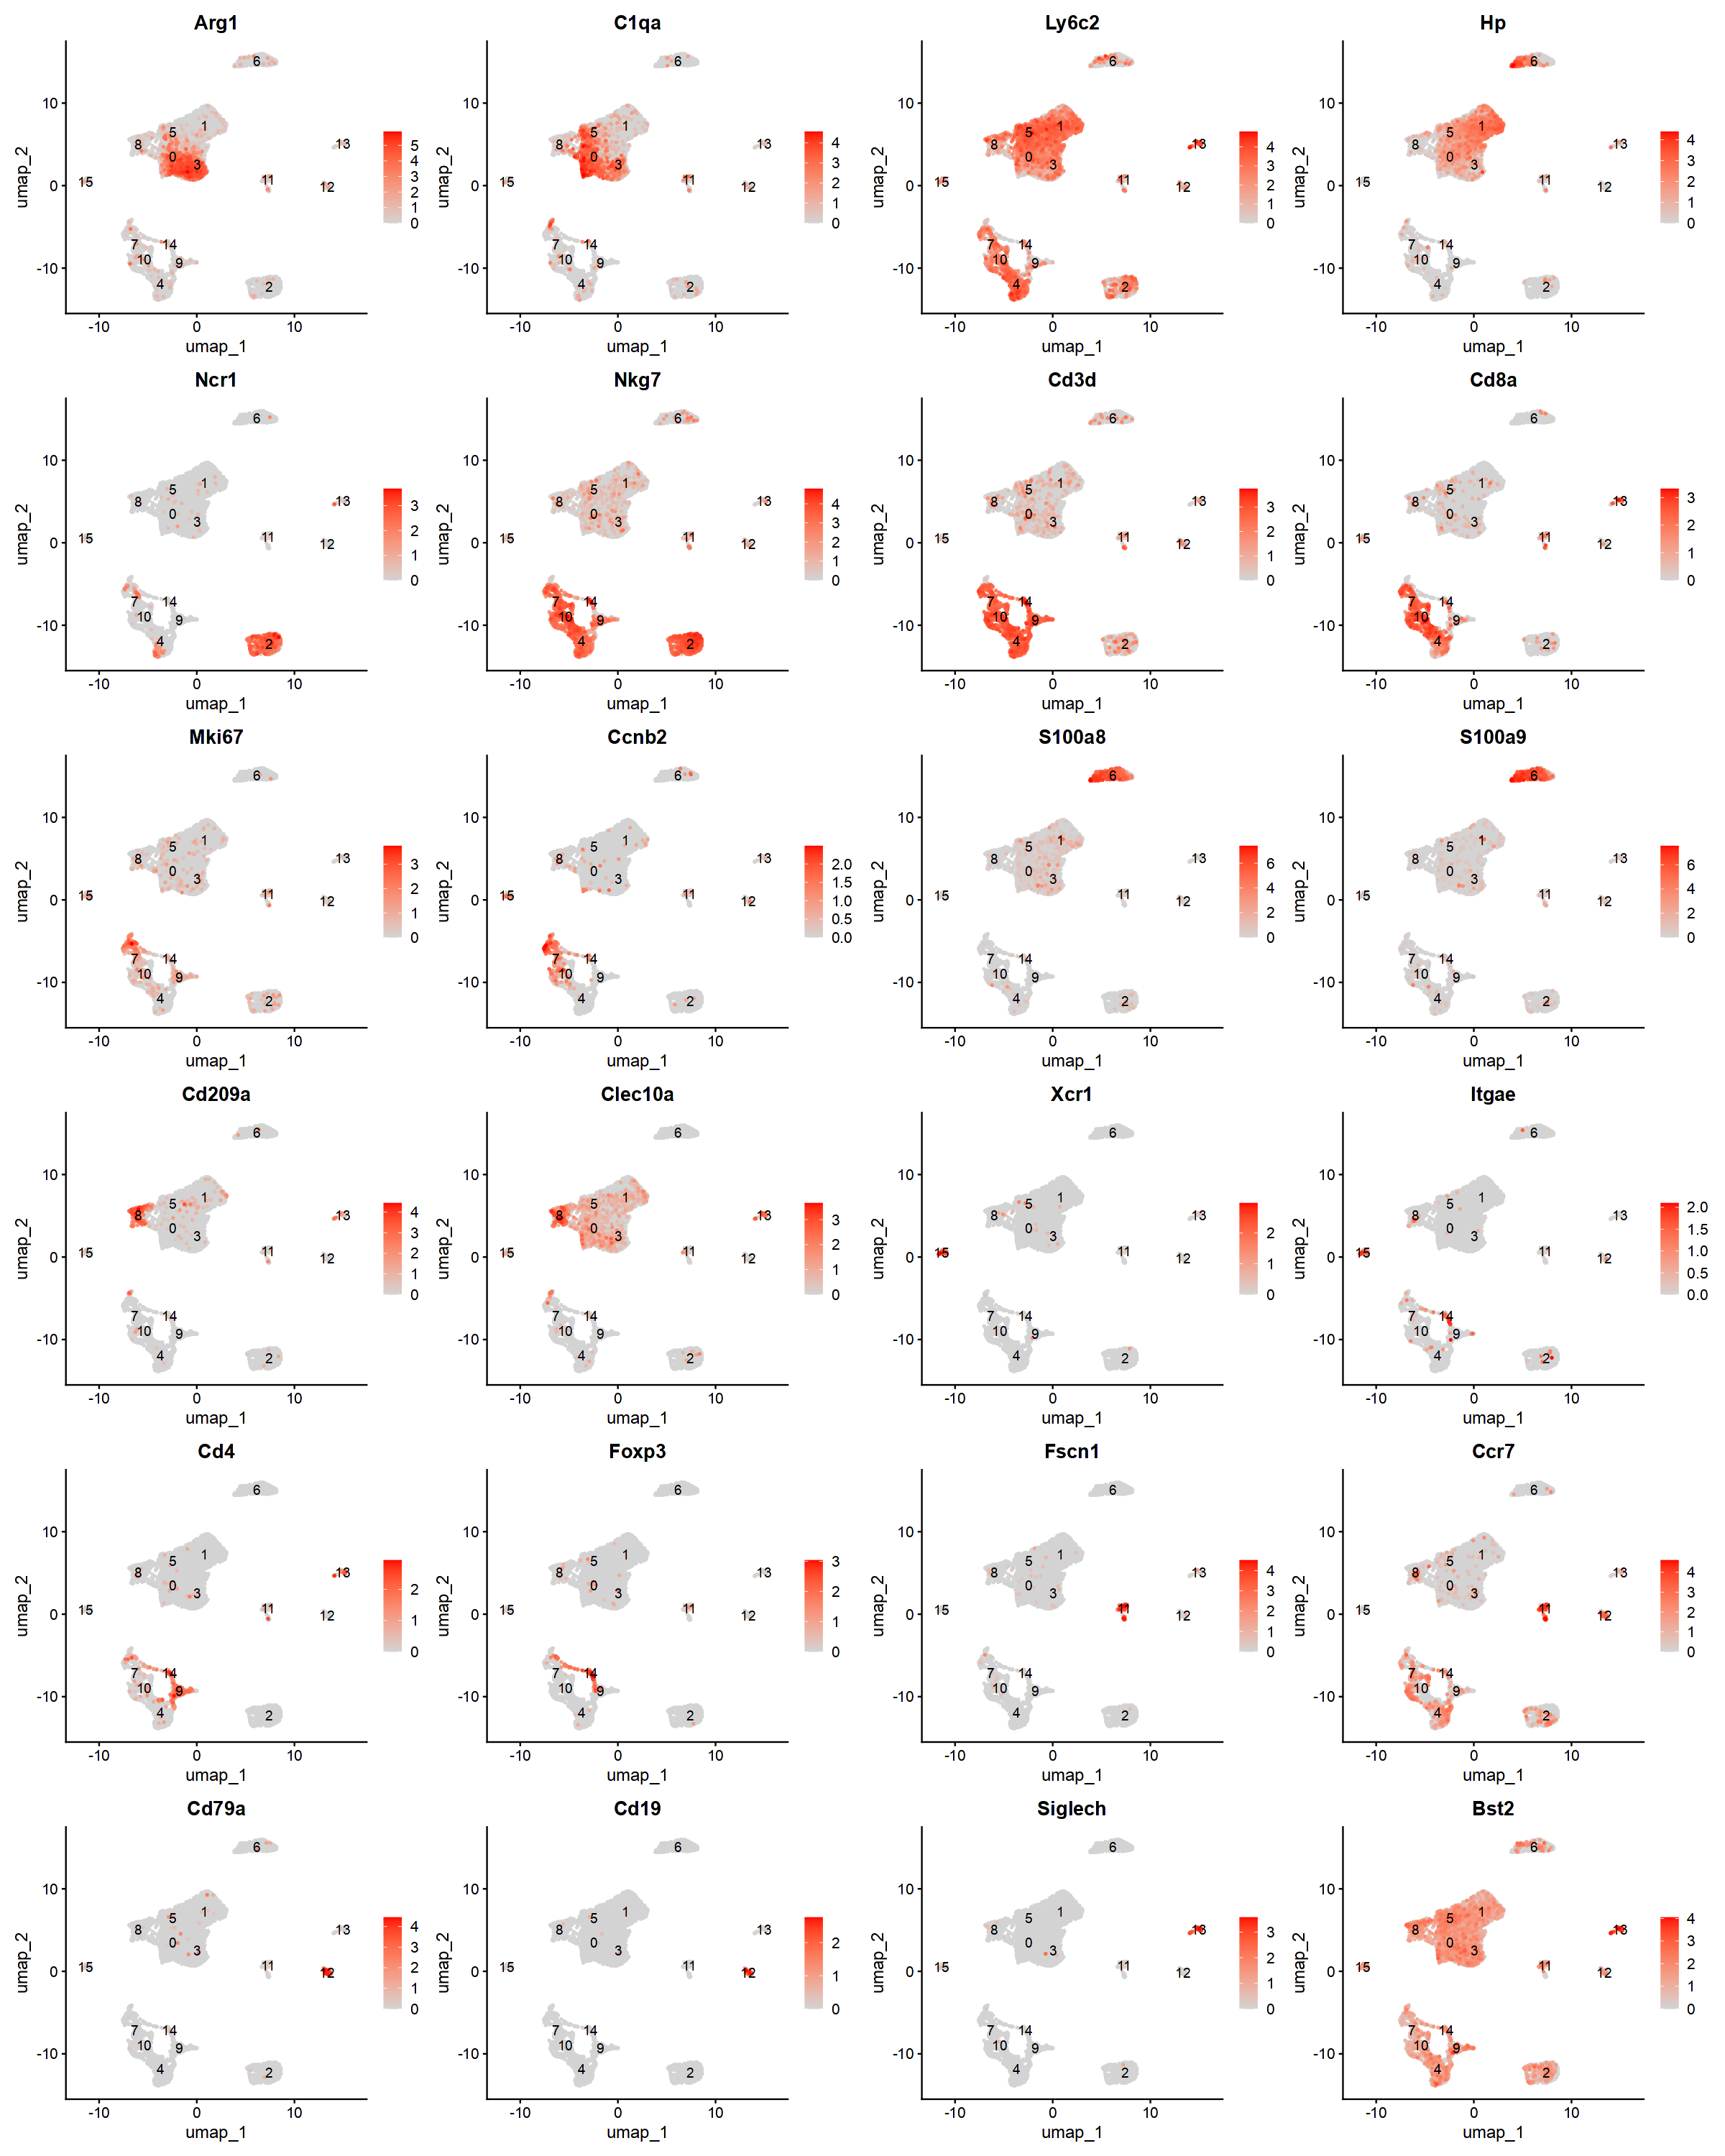

In [19]:
cluster_specific_genes1 <- c(
    "Arg1", "C1qa",#0 Macrophage
    "Ly6c2", "Hp",#1 Monocyte
    "Ncr1", "Nkg7",#2 NK
    "Cd3d", "Cd8a",#3 Cd8
    "Mki67", "Ccnb2",#4 Cycling Cd8
    "S100a8", "S100a9", #5 Neutrophil
    "Cd209a", "Clec10a", #6 cDC2
    "Xcr1", "Itgae", # cDC1
    "Cd4", "Foxp3", #7Cd4
    "Fscn1", "Ccr7", #8 cDC3
    "Cd79a", "Cd19", #9 B
    "Siglech", "Bst2"#10 pDC
)

options(repr.plot.width = 20, repr.plot.height = 25)
FeaturePlot(merged_filt, features = cluster_specific_genes1, 
            pt.size=0.3, label=T, order=T, ncol=4, cols = c("lightgrey", "red"))

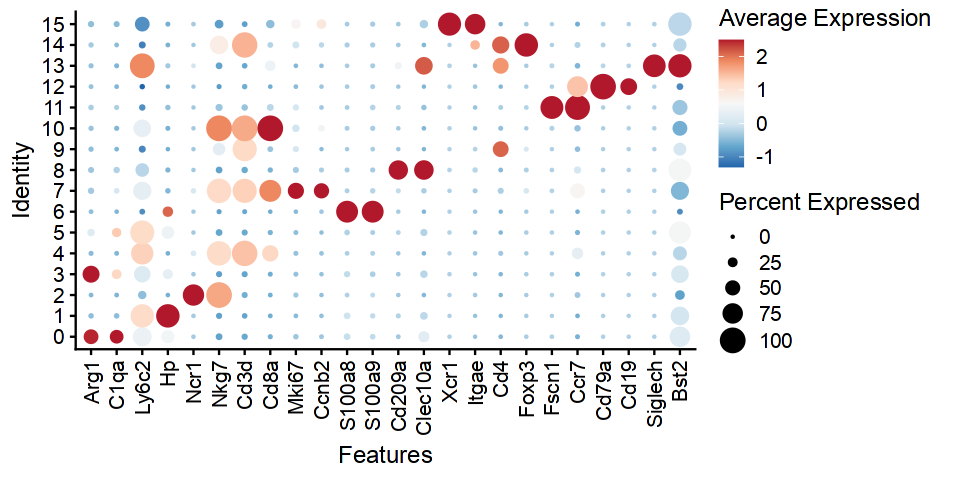

In [20]:
options(repr.plot.width = 8, repr.plot.height = 4)
DotPlot(merged_filt, features = cluster_specific_genes1, cols = "RdBu") + theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1))

In [21]:
saveRDS(merged_filt, file = file.path(dir_int, "merged_filt.rds"))